# Implémentation des Transformations de Fourier discrètes pour la compression

Nous utiliserons les bibliothèques suivantes :

*   numpy pour les opérations mathématiques
*   matplotlib pour les graphiques
*   PIL pour manipuler des images

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

Transformée de Fourier Rapide (FFT) avec l'algorithme de Cooley-Tukey :

In [2]:
def FFT(sig):
  N = len(sig)

  if N <= 1:
    return sig

  # On divise le signal en deux listes correspondant aux indices pairs et impairs sur lesquelles on applique la FFT
  pair = FFT(sig[::2])
  impair = FFT(sig[1::2])

  # On calcule les racines complexes omega^k
  omega = [np.exp(-2j * np.pi * k / N) for k in range(N // 2)]

  spectre_1 = [pair[k] + omega[k] * impair[k] for k in range(N // 2)] # Coefficients de 0 à n/2 - 1
  spectre_2 = [pair[k] - omega[k] * impair[k] for k in range(N // 2)] # Coefficients de n/2 à n - 1

  # On assemble les deux listes
  return spectre_1 + spectre_2

L'algorithme de Cooley-Tukey a une complexité en $O(n \log(n))$, il est donc bien plus efficace que l'algorithme naïf pour traiter les données de grande taille.

In [3]:
def TFD_naive(sig):
  N = len(sig)

  spectre = [0]*N

  for k in range(N):
    for n in range(N):
      spectre[k] += sig[n] * np.exp(-2j * np.pi * k * n / N)

  return spectre

On définit la transformée de Fourier inverse en utilisant le conjugué pour éviter de réécrire un autre algorithme similaire à celui de la FFT.

In [4]:
def IFFT(X):
  X = np.asarray(X, dtype=complex)
  N = len(X)
  X_conj = np.conjugate(X)
  return np.conjugate(FFT(X_conj)) / N

Afin de pouvoir manipuler des images, il faut pouvoir utiliser la FFT en deux dimensions. Pour ce faire, on applique d'abord la FFT sur chaque ligne de l'image originale. On obtient alors une matrice temporaire de coefficients complexes puis on applique la FFT sur chaque colonne de cette matrice.

In [5]:
def FFT_2D(im):
  h, l = im.shape
  lignes = np.array([FFT(im[i, :]) for i in range(h)])
  colonnes = np.array([FFT(lignes[:, j]) for j in range(l)]).T
  return colonnes

def IFFT_2D(coeffs):
  h, l = coeffs.shape
  colonnes = np.array([IFFT(coeffs[:, j]) for j in range(l)]).T
  lignes = np.array([IFFT(colonnes[i, :]) for i in range(h)])
  return np.real(lignes)

In [6]:
# Ouverture du fichier image.png
# On ne garde que les niveaux de gris

imageRGB = Image.open("image.png")
imageGris = imageRGB.convert("L")
image = np.array(imageGris)

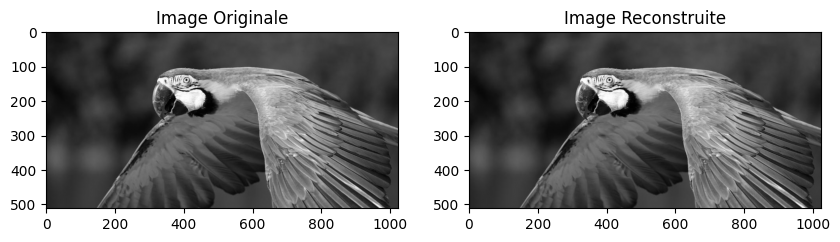

In [7]:
plt.figure(figsize=(10, 7))
plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.title("Image Originale")
plt.subplot(122)
image_reconstruite = IFFT_2D(FFT_2D(image))
plt.imshow(image_reconstruite, cmap='gray')
plt.title(f"Image Reconstruite")
plt.show()

Taille de l'image : (512, 1024)


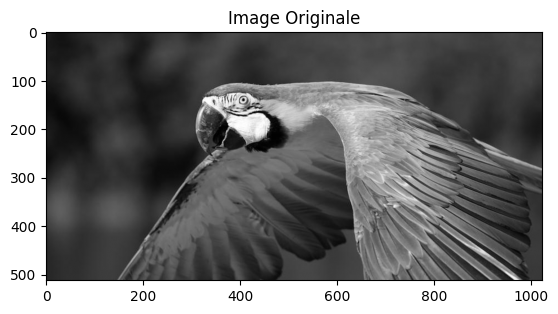

In [8]:
print(f"Taille de l'image : {image.shape}")
plt.imshow(image, cmap='gray')
plt.title("Image Originale")
plt.show()

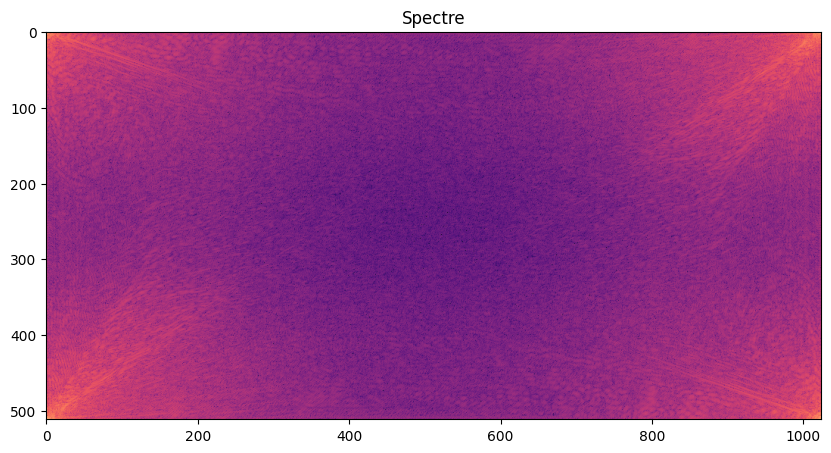

In [9]:
# FFT 2D
coeffs = FFT_2D(image)
spectre = np.log(1 + np.abs(coeffs))

plt.figure(figsize=(10, 7))
plt.imshow(spectre, cmap='magma')
plt.title("Spectre")
plt.show()

On observe que les valeurs élevées du spectre se situent sur les quatre coins de l'image. On peut échanger le quart de spectre supérieur gauche avec celui inférieur droit et celui inférieur gauche avec celui supérieur droit.

In [10]:
def FFT_shift(coeffs):
  h, l = coeffs.shape
  h //= 2
  l //= 2

  shift = np.zeros_like(coeffs)

  # Haut - Gauche
  shift[:h, :l] = coeffs[h:, l:]
  # Haut - Droite
  shift[:h, l:] = coeffs[h:, :l]
  # Bas - Gauche
  shift[h:, :l] = coeffs[:h, l:]
  # Bas - Droite
  shift[h:, l:] = coeffs[:h, :l]
  return shift

def IFFT_shift(coeffs):
  return FFT_shift(coeffs)

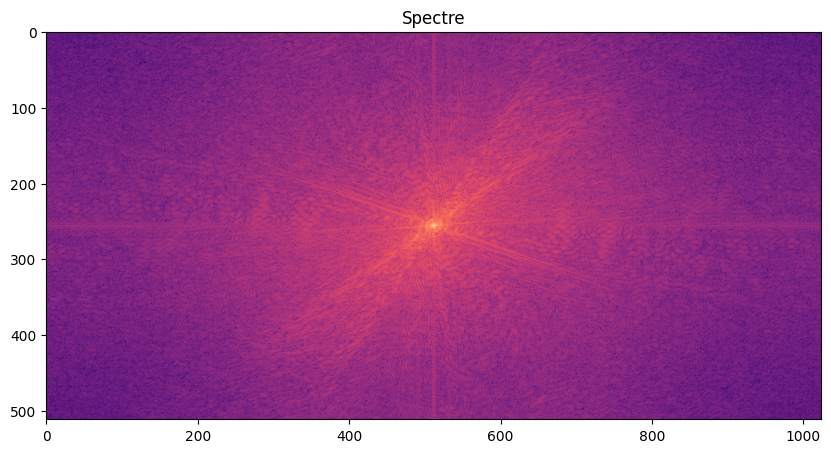

In [11]:
coeffs_s = FFT_shift(coeffs)
spectre = np.log(1 + np.abs(coeffs_s))

plt.figure(figsize=(10, 7))
plt.imshow(spectre, cmap='magma')
plt.title("Spectre")
plt.show()

On peut maintenant garder les fréquences les plus faibles qui sont contenues au centre du spectre. On ne garde ainsi que les fréquences situées dans un rectangle centré sur le milieu du spectre.

In [43]:
def masque_compression(coeffs_im, alpha):
  h, l = coeffs_im.shape
  masque = np.zeros((h, l))

  h_alpha = int(h * alpha / 2)
  l_alpha = int(l * alpha / 2)

  ch = h // 2
  cl = l // 2

  masque[ch - h_alpha : ch + h_alpha, cl - l_alpha : cl + l_alpha] = 1

  return coeffs_im * masque

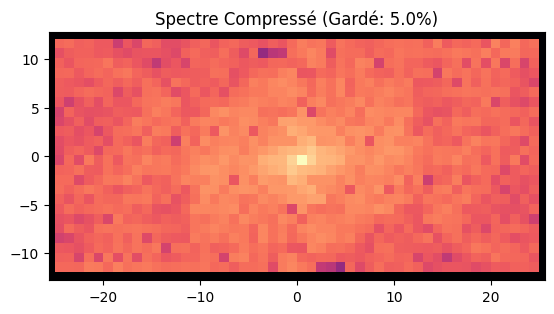

In [35]:
# Compression
alpha = 0.05
coeffs_compresses = masque_compression(coeffs_s, alpha)
spectre_compresse = np.log(1 + np.abs(coeffs_compresses))

h, l = spectre_compresse.shape

plt.imshow(spectre_compresse, cmap='magma', extent=[-l//2, l//2, -h//2, h//2], aspect='equal')
plt.title(f"Spectre Compressé (Gardé: {alpha*100}%)")
plt.xlim(-l * alpha / 2, l * alpha / 2)
plt.ylim(-h * alpha / 2, h * alpha / 2)
plt.show()


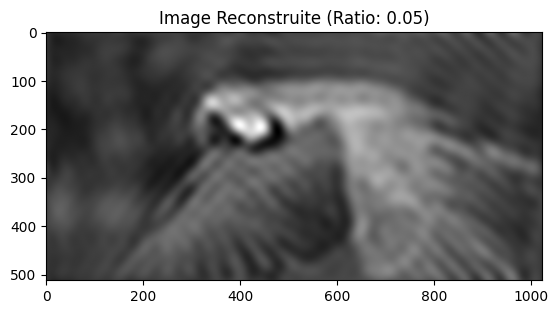

In [36]:
# Reconstruction
image_compressee = IFFT_2D(IFFT_shift(coeffs_compresses))
plt.imshow(image_compressee, cmap='gray')
plt.title(f"Image Reconstruite (Ratio: {alpha})")
plt.show()

In [15]:
# uint8 accepte seulement les valeurs entre 0 et 255
image_compressee = np.clip(image_compressee, 0, 255)
Image.fromarray(image_compressee.astype(np.uint8)).save('image_compressee.png')

In [52]:
def compresser(mat, alpha):
  coeffs = FFT_2D(mat)
  coeffs_s = FFT_shift(coeffs)
  coeffs_c = masque_compression(coeffs_s, alpha)
  return IFFT_2D(IFFT_shift(coeffs_c))

Nous avons vu comment compresser une image en niveaux de gris. Pour compresser une image avec des canaux RGB, il suffit de compresser chaque canal indépendamment des autres, puis de les réassembler pour former une image finale compressée.

In [71]:
imageRGB = Image.open("image.png")
image = np.array(imageRGB)
image_rouge = image[:,:,0]
image_vert = image[:,:,1]
image_bleu = image[:,:,2]

alpha = 0.1

image_comp_rouge = compresser(image_rouge, alpha)
image_comp_vert = compresser(image_vert, alpha)
image_comp_bleu = compresser(image_bleu, alpha)

image_comp_rgb = np.dstack((image_comp_rouge, image_comp_vert, image_comp_bleu))
image_comp_finale = np.clip(image_comp_rgb.real, 0, 255).astype(np.uint8)

<Figure size 1600x800 with 0 Axes>

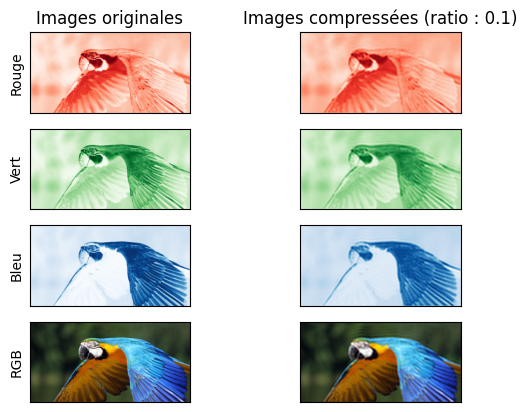

In [74]:
# Affichage
plt.figure(figsize=(16, 8))
fig, ax = plt.subplots(4, 2)
ax[0,0].imshow(image_rouge, cmap = 'Reds')
ax[0,1].imshow(image_comp_rouge, cmap = 'Reds')
ax[1,0].imshow(image_vert, cmap = 'Greens')
ax[1,1].imshow(image_comp_vert, cmap = 'Greens')
ax[2,0].imshow(image_bleu, cmap = 'Blues')
ax[2,1].imshow(image_comp_bleu, cmap = 'Blues')
ax[3,0].imshow(image)
ax[3,1].imshow(image_comp_finale)

ax[0,0].set_title("Images originales")
ax[0,1].set_title(f"Images compressées (ratio : {alpha})")

ax[0,0].set_ylabel("Rouge")
ax[1,0].set_ylabel("Vert")
ax[2,0].set_ylabel("Bleu")
ax[3,0].set_ylabel("RGB")

for i in range(4):
  for j in range(2):
    ax[i,j].set_xticks([])
    ax[i,j].set_yticks([])

plt.show()

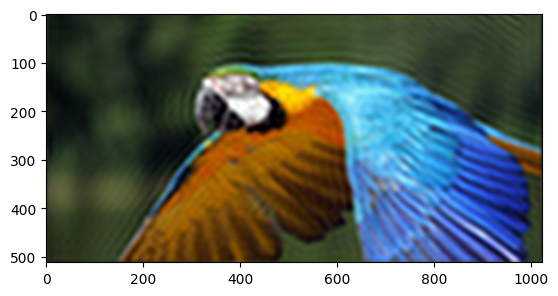

<Figure size 800x1000 with 0 Axes>

In [73]:
plt.imshow(image_comp_finale)
plt.figure(figsize=(8, 10))
plt.show()
Image.fromarray(image_comp_finale.astype(np.uint8)).save('image_compressee_rgb.png')